<div >
<img src = "figs/ans_banner_1920x200.png" />
</div>

# Caso-taller:  Segmentación de Clientes con Clustering Jerárquico y DBSCAN

El objetivo de este caso-taller es analizar una base de datos ficticia sobre clientes de una tienda y buscar encontrar grupos de clientes que permitan generar estrategias de marketing focalizadas. La base se encuentra en los `Archivos de Laboratorio` en la carpeta `data` y cuenta con 200 observaciones y 5 variables:

- `Id_Cliente`: identificador de cliente.
- `Genero`: género del cliente: Mujer, Hombre
- `Edad`: edad en años
- `Ingreso`: ingresos anuales
- `Puntaje_Gasto`: es una variable que mide cuán a menudo un cliente compra en la tienda, siendo 100 el puntaje más alto.


## Instrucciones generales

1. Para desarrollar el *cuaderno* primero debe descargarlo.

2. Para responder cada inciso deberá utilizar el espacio debidamente especificado.

3. La actividad será calificada sólo si sube el *cuaderno* de jupyter notebook con extensión `.ipynb` en la actividad designada como "entrega calificada por el personal".

4. El archivo entregado debe poder ser ejecutado localmente por el tutor. Sea cuidadoso con la especificación de la ubicación de los archivos de soporte, guarde la carpeta de datos en el mismo `path` de su cuaderno, por ejemplo: `data`.

## Importar librerias

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial import distance_matrix
from sklearn.cluster import DBSCAN
from sklearn.datasets import make_blobs
from sklearn.neighbors import NearestNeighbors
from kneed import KneeLocator
from sklearn import datasets, cluster
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
from scipy.spatial.distance import pdist
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.cluster.hierarchy import dendrogram
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import gower

## Desarrollo


### 1.Carga de datos 

En la carpeta `data` se encuentra el archivo `datos_clientes.csv` cargue estos datos en su *cuaderno*. 

In [2]:
df = pd.read_csv("datos_clientes.csv")
df.head()

,Id_Cliente,Genero,Edad,Ingreso,Puntaje_Gasto
0,1,Mujer,41,98115.05,39
1,2,Mujer,20,35458.14,75
2,3,Mujer,68,59872.08,55
3,4,Hombre,63,48508.93,51
4,5,Mujer,31,44431.11,54


Garantizando que el archivo "datos_clientes.csv" se encuentre dentro del path del notebook, se carga el archivo y se genera una carga inicial de los datos para validar su contenido preliminarmente. El archivo queda almacenado en un dataframe.

### 2. Análisis preliminar. 

Antes de comenzar el análisis de segmentación utilice estadísticas descriptivas para explorar la variables que se encuentran en los datos. En su análisis mencione si hay patrones que surgen del examen descriptivo de los datos; entre ellos si hay diferencias en los ingresos y los puntajes de gastos para mujeres y hombres, por grupos etarios (18-24, 25-34, 35-44, 45-54, 55-64, y 65+), y por grupos etarios y género. Discuta además si estas diferencias son estadísticamente significativas.

#### Análisis general

In [4]:
df.shape

(200, 5)

Dentro del dataset, podemos confirmar inicialmente, que contamos con 5 columnas y 200 registros dentro de la tabla

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id_Cliente     200 non-null    int64  
 1   Genero         200 non-null    object 
 2   Edad           200 non-null    int64  
 3   Ingreso        200 non-null    float64
 4   Puntaje_Gasto  200 non-null    int64  
dtypes: float64(1), int64(3), object(1)
memory usage: 7.9+ KB


De la información obtenida de la función ".info()" se puede observar:
- las diferentes columnas que tiene el dataset junto con sus tipos de datos: Id_Cliente (número entero), Genero (probablemente represente una cadena de texto), Edad (número entero), Ingreso (número con decimales), Puntaje_Gasto (número entero).
- Que ninguna de las columnas cuenta con registros nulos

In [11]:
df_categoricas = df['Genero']
df_numericas = df.drop(columns=['Genero'])

In [13]:
for i in df.columns:
    print(f'{i} : {df[i].unique()} \n --------------------------------- \n')

Id_Cliente : [  1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17  18
  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35  36
  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53  54
  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71  72
  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89  90
  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107 108
 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125 126
 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143 144
 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161 162
 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179 180
 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197 198
 199 200] 
 --------------------------------- 

Genero : ['Mujer' 'Hombre'] 
 --------------------------------- 

Edad : [41 20 68 63 31 32 19 28 24 44 25 67 34 35 59 58 40 23 38 48 18

Con base en la información observada, podemos confirmar que además de no tener valores nulos, los campos del dataset tampoco cuentan con inconsistencias en los datos. Al menos desde un punto de vista general

In [16]:
df_categoricas.value_counts()

Mujer     112
Hombre     88
Name: Genero, dtype: int64

Se puede observar que del total de registros, el 56% corresponde a mujeres y el 44% a hombres. Lo cual nos ayuda a entender que las clases para esta variable no están del todo valanceadas 50/50

In [19]:
df_numericas.describe()

,Id_Cliente,Edad,Ingreso,Puntaje_Gasto
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60624.446600,50.200000
std,57.879185,13.969007,26262.903416,25.823522
min,1.000000,18.000000,13458.020000,1.000000
25%,50.750000,28.750000,41512.787500,34.750000
50%,100.500000,36.000000,60777.960000,50.000000
75%,150.250000,49.000000,77143.865000,73.000000
max,200.000000,70.000000,138584.520000,99.000000


Dentro de la información que nos arroja la función ".describe()" podemos sacar las siguientes conclusiones:
- Los ID_Cliente son únicos y no se repiten
- La edad promedio del dataset es 39 años con una desviación estándar de 13.96 y valores máximos y mínimos de 18 y 70 respectivamente
- En la variable ingresos se puede evidenciar la presencia de outliers, ya que el P25,P75 y P100 tienen valores de 41,512.78 77,143.86 138,584.52 respectivamente. Entre el P75 y P100 hay un salto bastante grande
- El puntaje de gasto, tal como se mencionó en el enunciado, toma valores entre 1 y 99

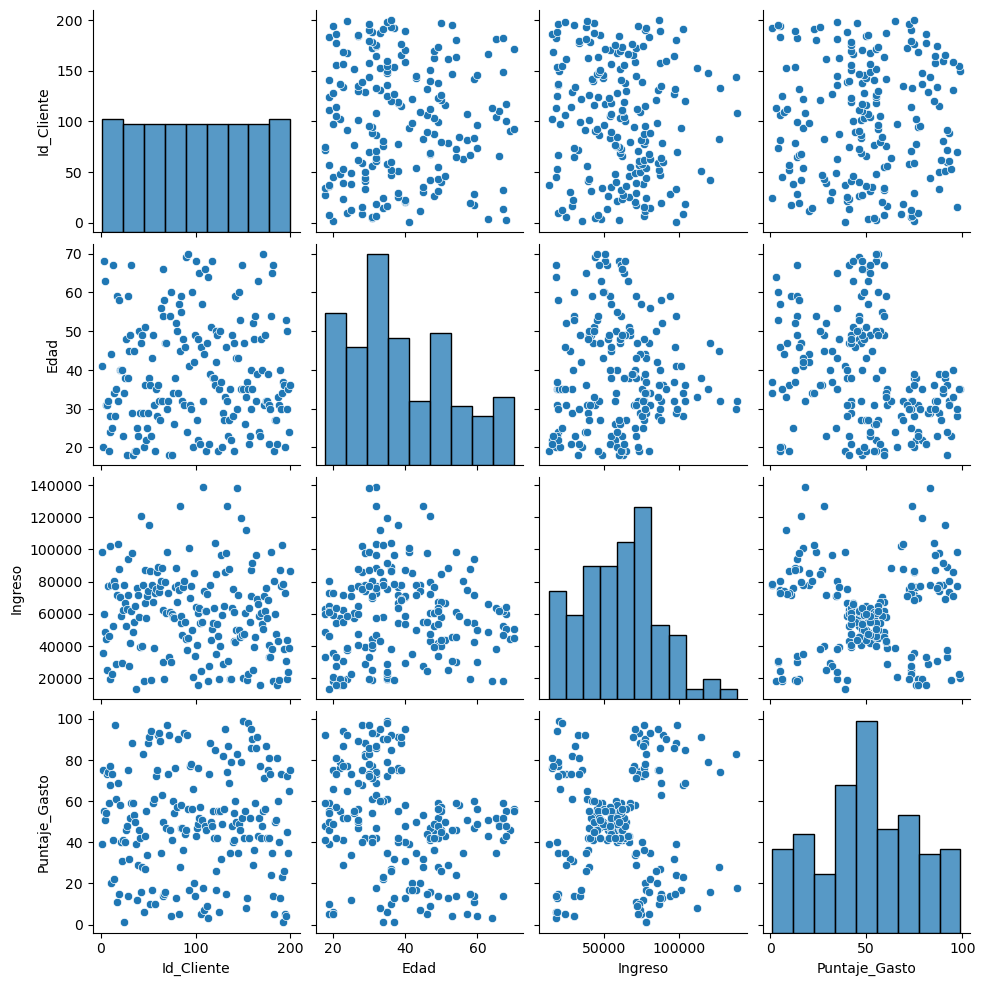

In [22]:
sns.pairplot(df_numericas, kind="scatter")
plt.show()

A partir del gráfico anterior se puede entender que en el dataset:
- No parece haber dependencia lineal entre las variables numéricas
- El gráfico de dispersión de la variable puntaje_gasto y la variable ingreso, parecen mostrar un comportamiendo casi de clusters. Uno en el centro muy marcado y cuatro al rededor un poco más dispersos
- En cuando a los histogramas, a diferencia de la variable id_cliente que se ve uniforme, las demás variables no muestran algún comportamiento particular. Aunque el puntaje del gasto parezca asemejarse a un comportamiento normal, en cuyo caso de debería confirmar a través de pruebas estadísticas
- La relación entre las diferentes variables no parece seguir algún patrón especial. Excepto el descrito para las variables puntaje_gasto y la variable ingreso

**Para entender las diferencias en los ingresos y los puntajes de gastos para mujeres y hombres, por grupos etarios (18-24, 25-34, 35-44, 45-54, 55-64, y 65+), y por grupos etarios y género. Discuta además si estas diferencias son estadísticamente significativas; se utilizarán box-plot como herramienta principal ya que permite gráficamente entender las relaciones entre variables, medias, comparar desviaciones estándar, minimos, máximos, entre otros**

#### Relación ingresos y puntaje de gasto por género

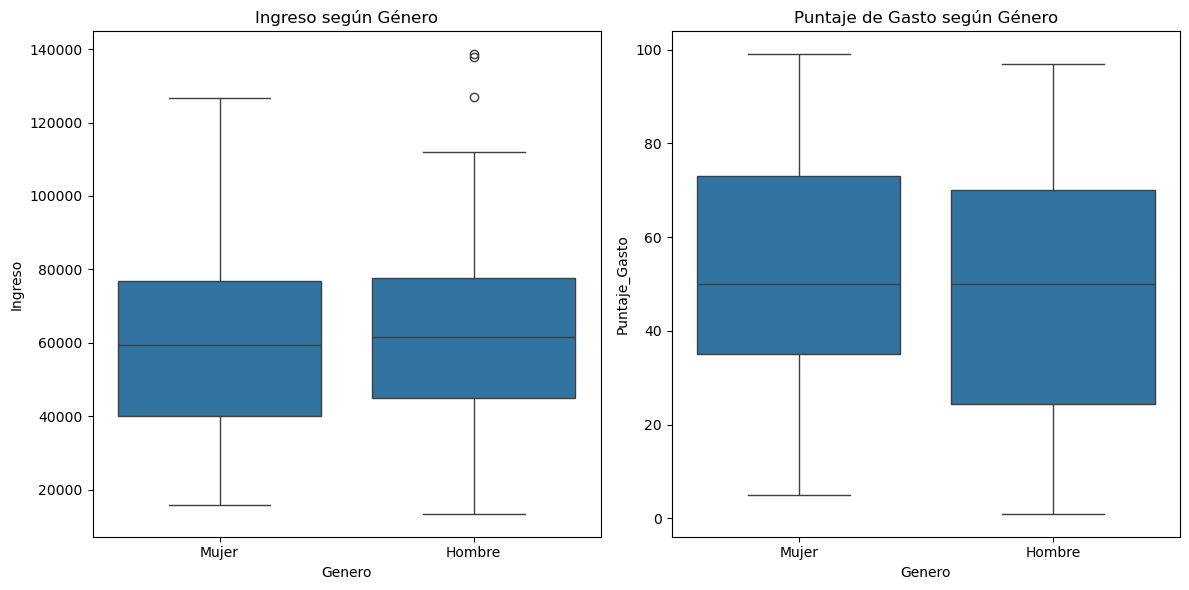

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(12,6))

# Boxplot Ingreso por Género
sns.boxplot(x='Genero', y='Ingreso', data=df, ax=axes[0])
axes[0].set_title('Ingreso según Género')

# Boxplot Puntaje_Gasto por Género
sns.boxplot(x='Genero', y='Puntaje_Gasto', data=df, ax=axes[1])
axes[1].set_title('Puntaje de Gasto según Género')

plt.tight_layout()
plt.show()

Con base en este gráfico podemos determinar los siguiente acerca del comportamiento por género en cuando a ingresos y puntaje de gasto:

- Los ingresos promedio entre hombres y mujeres son muy semejantes
- El puntaje de gasto promedio entre hombres y mujeres es muy similar
- Los ingresos de los hombres suelen estar un poco por encima de los ingresos para las mujeres, pero más impulsados por algunos valores átipicos presentes en los ingresos de los hombres que no se ven en los ingresos de mujeres
- El puntaje de gasto para las mujeres parece estar un poco por encima del puntaje de gasto para los hombres. De igual forma hay una proporción importante de mujeres que tienen un puntaje de gasto por encima a la media.
- En cuanto a outliers o valores átipicos en el puntaje de gasto, no se evidencian para el conjunto de datos para ningún género en particular


#### Relación ingresos y puntaje de gasto por grupo etario

In [31]:
bins = [17, 24, 34, 44, 54, 64, float('inf')]
labels = ['18-24', '25-34', '35-44', '45-54', '55-64', '65+']
df['grupo_etario'] = pd.cut(df['Edad'], bins=bins, labels=labels, right=True)

In [33]:
df

,Id_Cliente,Genero,Edad,Ingreso,Puntaje_Gasto,grupo_etario
0,1,Mujer,41,98115.05,39,35-44
1,2,Mujer,20,35458.14,75,18-24
2,3,Mujer,68,59872.08,55,65+
3,4,Hombre,63,48508.93,51,55-64
4,5,Mujer,31,44431.11,54,25-34
...,...,...,...,...,...,...
195,196,Mujer,30,19322.17,72,25-34
196,197,Mujer,50,43486.37,45,45-54
197,198,Hombre,35,24086.95,35,35-44
198,199,Mujer,24,38599.28,65,18-24


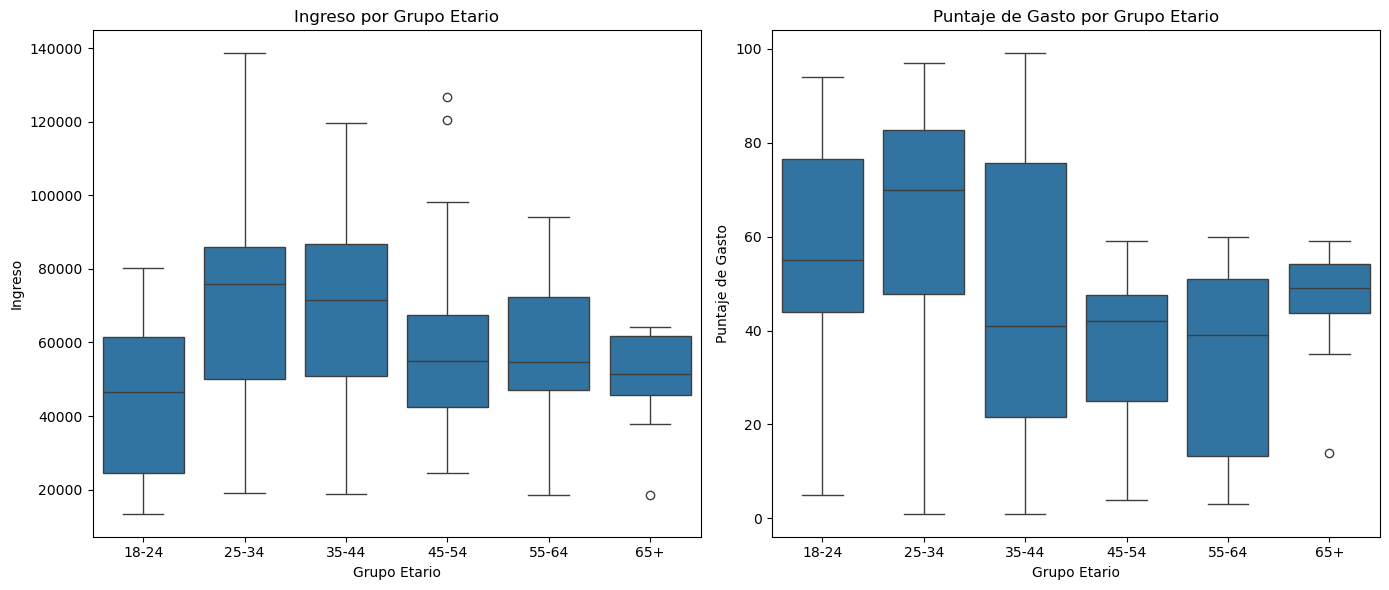

In [35]:
# Crear figura con 2 boxplots
fig, axes = plt.subplots(1, 2, figsize=(14,6))

# Boxplot Ingreso
sns.boxplot(x='grupo_etario', y='Ingreso', data=df, ax=axes[0])
axes[0].set_title('Ingreso por Grupo Etario')
axes[0].set_xlabel('Grupo Etario')
axes[0].set_ylabel('Ingreso')

# Boxplot Puntaje_Gasto
sns.boxplot(x='grupo_etario', y='Puntaje_Gasto', data=df, ax=axes[1])
axes[1].set_title('Puntaje de Gasto por Grupo Etario')
axes[1].set_xlabel('Grupo Etario')
axes[1].set_ylabel('Puntaje de Gasto')

plt.tight_layout()
plt.show()

En el procedimiento anterior, se creó en el dataframe una nueva variable categorica, denominada grupo_etario, que separa las edades por rangos: 18-24, 25-34, 35-44, 45-54, 55-64, y 65+. A partir de esto, se crean gráficos box-plot para entender el comportamiento por grupo etario para el ingreso y el puntaje de gasto determinando lo siguiente:

**Frente a los ingresos**

- Los ingresos promedio para el rango de edad entre 18 y 24 años, es el menor ingreso promedio por grupo etario. Esto se puede comprender dado que en estos rangos de edad las personas aún no han terminado de ingresar en su etapa productiva.
- Los grupos etarios de 25 a 34 años y 35 a 44 años son los grupos con mayor ingreso promedio. Esto se entiende dado que para el rango de edad de 25 a 44 años es la edad de mayor productividad económica de una persona.
- Los grupos etarios de 45 a 54 años, 55 a 64 años y mayores a 65 años, tienen un ingreso promedio menor al grupo etario de 25 a 44 años y mayor al grupo etario de 18 a 24 años.
- La desviación estándar del ingreso para el grupo etario de mayores de 65 años, es la menor de todas y se evidencia que a medida que disminuye la edad, mayor es la dispersión.

**Frente al puntaje de gasto promedio**

- Contrario a lo evidenciado en el análisis de ingresos, el grupo etario con menor puntaje de gasto son los grupos de 35 a 44 años, 45 a 54 y 55 a 64 años con una media de puntaje de gasto que ronda el 40
- Por su parte, el grupo etario con mayor puntaje de gasto es el de 25 a 34 años con una media cercana a los 72 puntos
- El grupo etario de 18 a 24 años, a pesar de tener la menor media de ingreso, tiene la segunda mayor media de puntaje de gasto con un puntaje cercano a 55 puntos
- La desviación estándar del puntaje de gasto para el grupo etario de mayores de 65 años, es la menor de todas.

#### Relación ingresos y puntaje de gasto por género y grupo etario

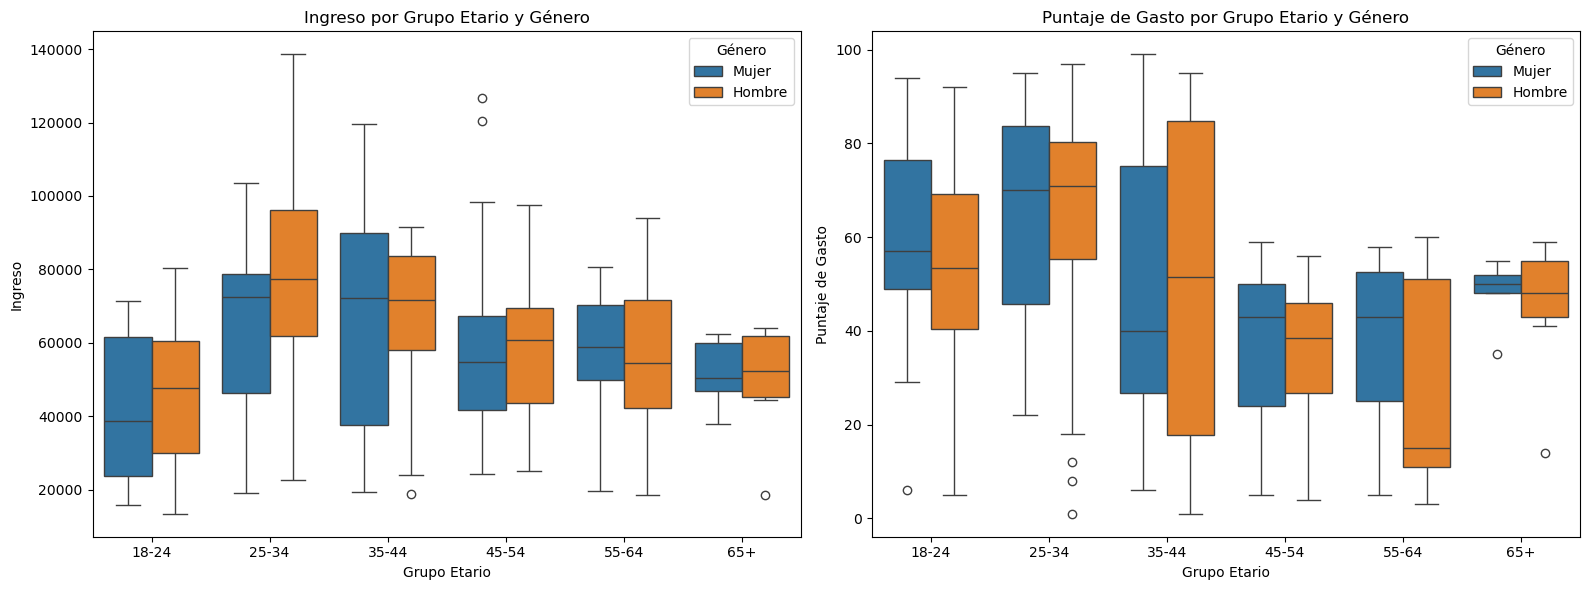

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(16,6))

# Boxplot Ingreso
sns.boxplot(x='grupo_etario', y='Ingreso', hue='Genero', data=df, ax=axes[0])
axes[0].set_title('Ingreso por Grupo Etario y Género')
axes[0].set_xlabel('Grupo Etario')
axes[0].set_ylabel('Ingreso')
axes[0].legend(title='Género')

# Boxplot Puntaje_Gasto
sns.boxplot(x='grupo_etario', y='Puntaje_Gasto', hue='Genero', data=df, ax=axes[1])
axes[1].set_title('Puntaje de Gasto por Grupo Etario y Género')
axes[1].set_xlabel('Grupo Etario')
axes[1].set_ylabel('Puntaje de Gasto')
axes[1].legend(title='Género')

plt.tight_layout()
plt.show()

Con base en los hallazgos anteriormente encontrados para el análisis de la relación de ingresos y puntaje de gasto por género y grupo etario, a partir del siguiente gráfico podemos determinar:

**Frente a los ingresos**

- En los grupos etarios de 18 a 24 años, 25 a 34 años 45 a 54 años y mayores a 65 años, el ingreso promedio de las mujeres es inferior al ingreso promedio de los hombres. Sin embargo, en el grupo etario de 35 a 44 y 55 a 64 años, los ingresos promedio de los hombre son menores al de las mujeres mientras que el grupo etario de 35 a 44 años tiene una media de ingresos muy similar entre ambos géneros
- En la etapa de mayor productividad de una persona, de 25 a 54 años, los ingresos promedio de los hombres son superiores a los de las mujeres
- En general, la desviación estándar de las mujeres, para un rango de edad de 18 a 24 años, es menor a la de los hombres. Mientras que para el rango de edad de mayores de 45 años, es mayor
- En general, los ingresos promedio por género suelen ser muy parecidos para todos los grupos etarios.

**Frente al puntaje de gasto**

- En general, la desviación estándar de las mujeres, para grupos etarios como 25 a 34 años y 45 a 54 años, es menor a la de los hombres. Caso contrario para los demás grupos etarios
- En términos generales, el promedio de puntaje por gasto, es meyor para las mujeres en todos los grupos etarios, exepto para los grupos de 35 a 44 años y ligeramente 25 a 34 años.
- A diferencia del ingreso, en algunos grupos etarios se ve una marcada diferencia entre la media de puntaje de gasto para mujeres y hombres. Por ejemplo en el grupo etario de 55 a 64 años, el puntaje de gasto promedio de las mujeres es de al rededor de 45 puntos mientras que para los hombres es de al rededor de 15 puntos

### 3. Clustering Jerárquico

#### 3.1. Dendrogramas

Agrupe a los clientes utilizando sólo dos variables: su ingreso y el puntaje de gastos. Para ello retenga estas dos variables, estandarízelas, construya y grafique un dendograma. Para la construcción del dendrograma utilice el enlace 'ward' y la distancia euclidiana. Explique la importancia de estandarizar los datos.

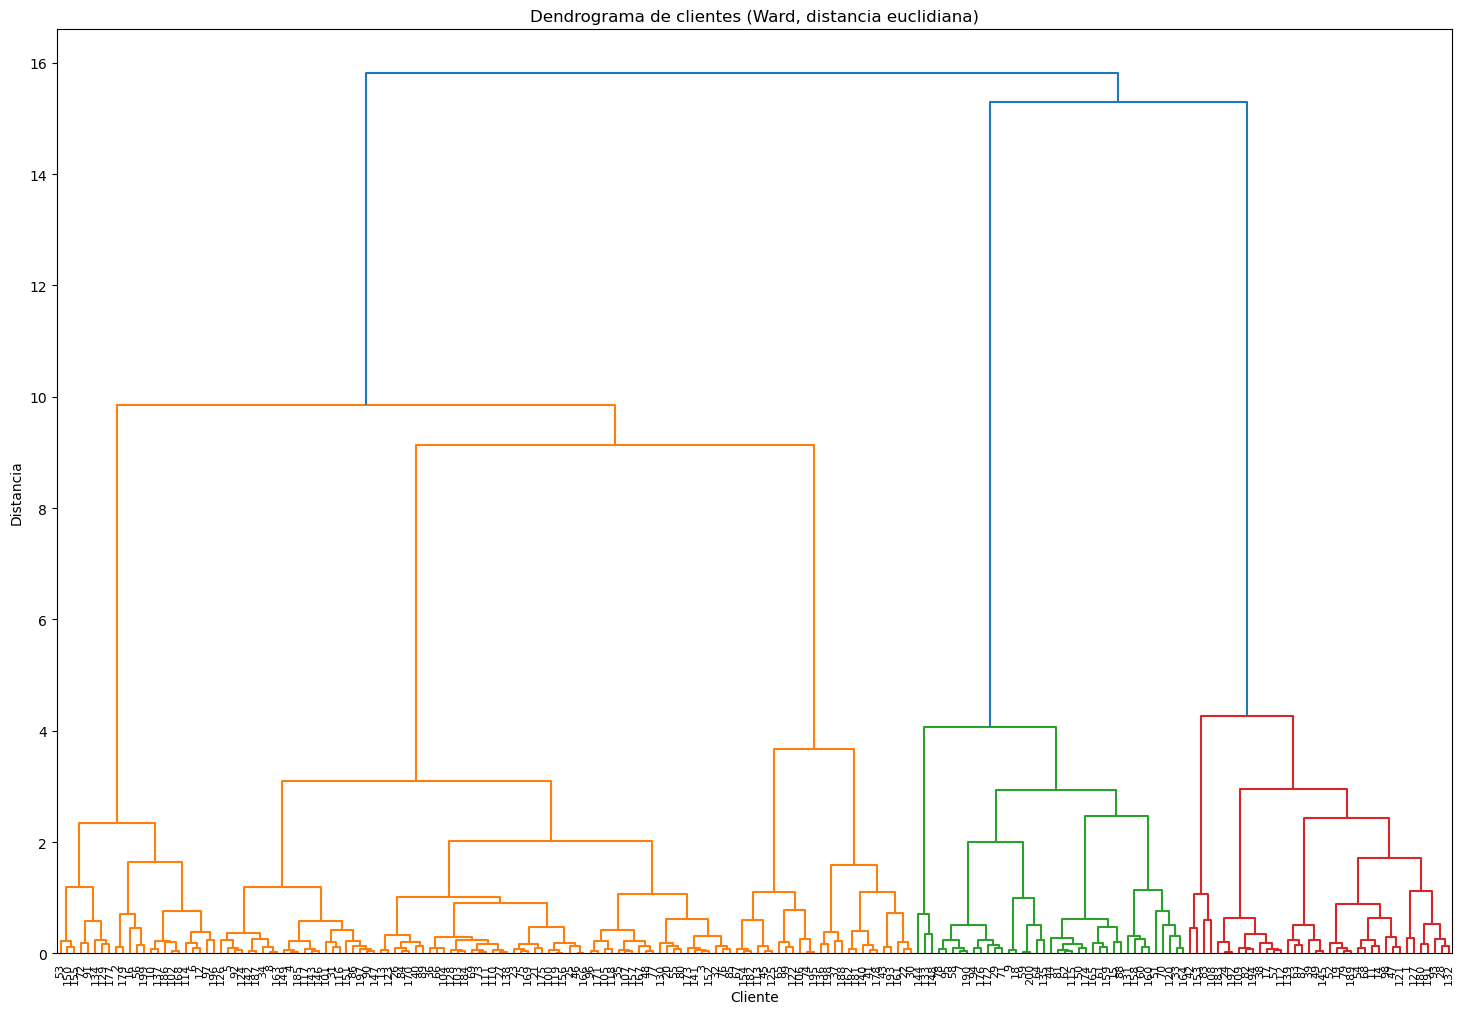

In [43]:
X = df[['Ingreso', 'Puntaje_Gasto']]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Z = linkage(X_scaled, method='ward', metric='euclidean')

# 4. Graficar dendrograma
plt.figure(figsize=(18, 12))
dendrogram(Z, labels=df['Id_Cliente'].values, leaf_rotation=90, leaf_font_size=8)
plt.title("Dendrograma de clientes (Ward, distancia euclidiana)")
plt.xlabel("Cliente")
plt.ylabel("Distancia")
plt.show()

De acuerdo a los solicitado por el enunciado, como medida inicial se crea X el cual está compuesto por dos variables: Ingreso y Puntaje de Gasto, de igual forma se estandarizan los datos y se construye el endograma.

La importancia de estandarizar los datos radica en las diferencias de escalas entre ambas variables. Mientras el ingreso promedio se mueve en un rando de entre 13,458 y 138,584; el puntaje de gasto se mueve en un rando entre 0 y 1, por lo que la estandarización permite reducir estas diferencias y no darle mayor relevancia a una variable sobre otra en términos de su escala de valor ya que en un endograma el agrupamiento se basa en las distancias entre observaciones y el no estandarizar puede arrojar clusters equivocados.

#### 3.2. Número de clusters

Retenga el número de clusters que se obtengan luego de fijar la distancia en 6.

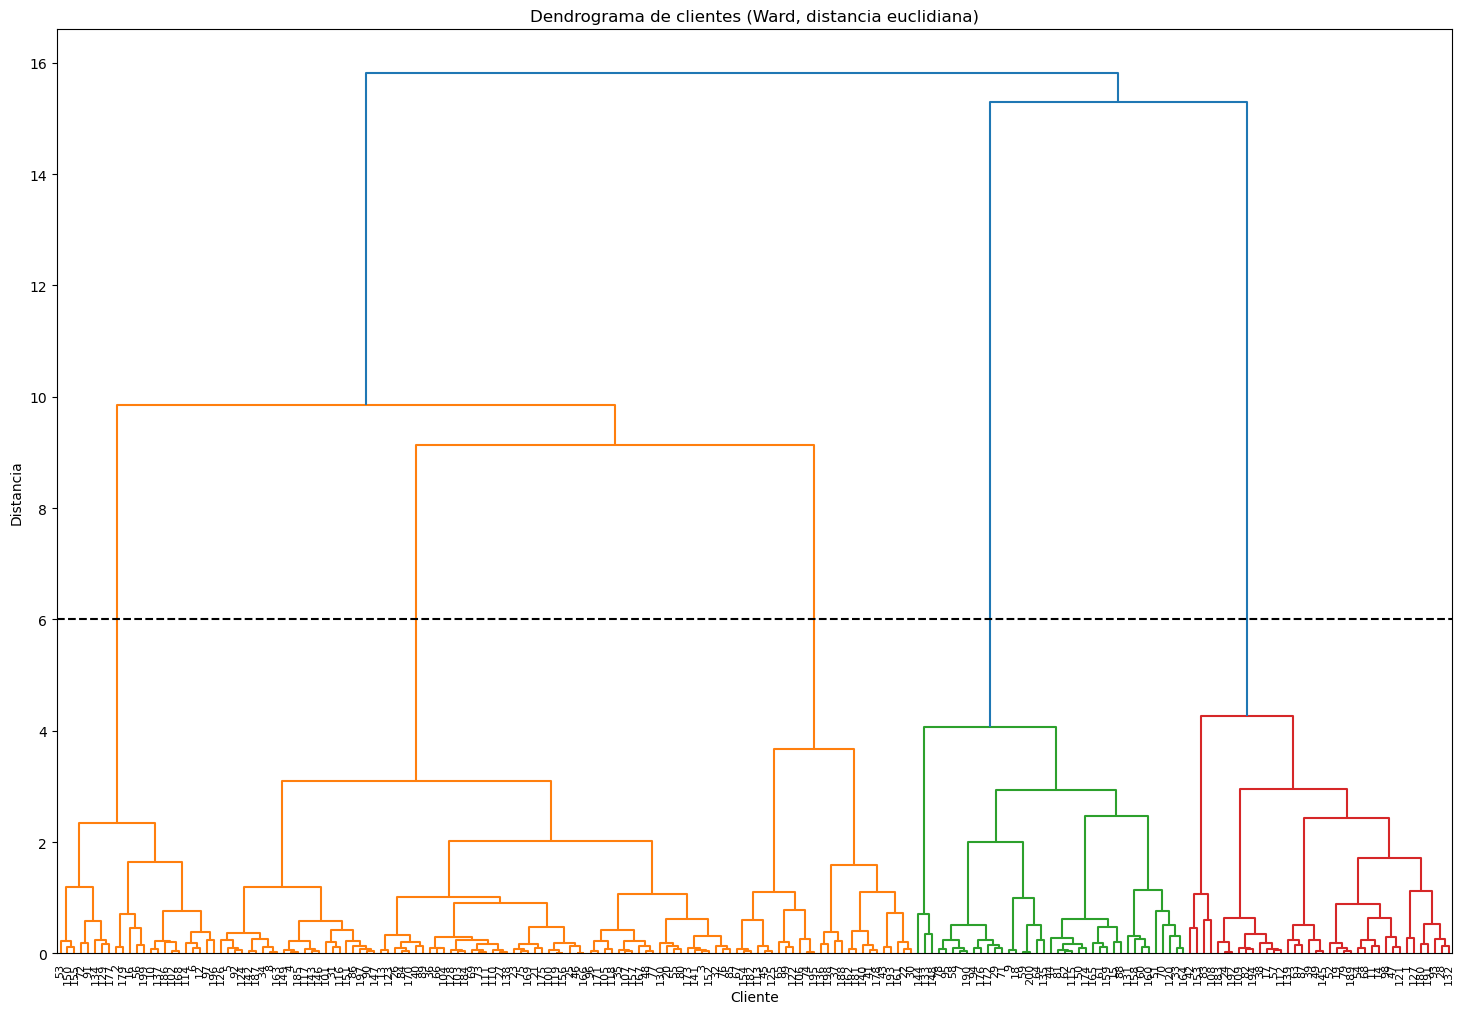

In [47]:


X = df[['Ingreso', 'Puntaje_Gasto']]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Z = linkage(X_scaled, method='ward', metric='euclidean')

# 4. Graficar dendrograma
plt.figure(figsize=(18, 12))
dendrogram(Z, labels=df['Id_Cliente'].values, leaf_rotation=90, leaf_font_size=8)
plt.axhline(y=6, color='black', linestyle='--')
plt.title("Dendrograma de clientes (Ward, distancia euclidiana)")
plt.xlabel("Cliente")
plt.ylabel("Distancia")
plt.show()

In [49]:
clusters = fcluster(Z, t=6, criterion='distance')
num_clusters = len(set(clusters))

print("Número de clusters:", num_clusters)

Número de clusters: 5


Para la realización de este punto, se traza una linea punteada al gráfico anterior para poder reflejar de forma gráfica el número de clusters con una distancia fijada en 6. De igual forma se utiliza la función fclusters de la librería scipy.

Por ambos procedimientos llegamos a la conclusión que el número de clusters que se botienen luego de fijar una distancia igual a 6 es de **5 clusters** que se almacenan en la variable num_clusters

#### 3.3. Algoritmo Jerárquico Aglomerativo

Utilizando el número de clusters encontrados en el paso anterior, aplique el algoritmo jerárquico aglomerativo, utilizando el enlace 'ward' y la distancia euclidiana. Describa los grupos encontrados, en que grupo o grupos concentraría su estrategia de marketing y por qué?

In [53]:
agglo = AgglomerativeClustering(n_clusters=num_clusters,metric='euclidean', linkage='ward')

labels = agglo.fit_predict(X_scaled)

print(labels)

[0 3 4 4 4 3 2 4 2 3 0 3 4 0 2 3 0 2 0 4 4 1 4 0 4 4 4 0 2 1 4 4 2 4 4 4 1
 0 0 4 1 0 1 2 1 4 0 4 0 2 2 0 3 0 4 3 0 2 2 2 2 2 0 2 1 4 1 0 4 2 2 3 4 1
 4 4 4 2 0 4 2 0 0 4 4 4 0 2 4 4 3 4 0 2 2 4 3 0 1 4 4 3 4 4 4 1 4 0 0 4 4
 0 1 3 2 4 4 4 4 2 0 1 4 4 1 4 0 4 3 4 2 0 2 3 2 1 3 4 0 1 4 4 4 2 0 4 4 2
 4 3 4 4 0 1 3 4 4 2 2 2 1 1 4 2 2 4 4 3 4 4 4 2 4 2 4 2 3 1 3 0 1 1 0 4 4
 3 4 1 0 2 0 0 1 0 1 3 4 1 3 2]


In [55]:
df['cluster'] = labels
df.groupby('cluster')[['Ingreso','Puntaje_Gasto']].describe()

Ingreso                                                               \
          count          mean           std       min         25%        50%   
cluster                                                                        
0          38.0  87055.074474  16200.102296  70888.72  75765.5100  80570.395   
1          26.0  28274.667308   8998.503308  13458.02  19362.5200  28787.940   
2          39.0  86537.496410  16684.184918  68486.79  75875.5150  77996.300   
3          23.0  26230.419565   7742.413865  15766.84  19590.8100  24905.790   
4          74.0  55451.258514   7847.567060  40218.68  48594.1075  57359.505   

                               Puntaje_Gasto                              \
                75%        max         count       mean        std   min   
cluster                                                                    
0        95988.5700  138584.52          38.0  18.631579  10.915947   1.0   
1        37203.2775   43155.28          26.0  23.307692  13.959281   3.0   
2        93952.4400  137838.57          39.0  82.128205   9.364489  63.0   
3        33157.7100   38950.66          23.0  78.565217  10.953729  61.0   
4        61796.6375   70469.66          74.0  50.216216   5.871385  40.0   

                                   
           25%   50%    75%   max  
cluster                            
0        10.25  16.5  26.75  40.0  
1        13.25  27.0  35.00  42.0  
2        74.50  83.0  90.00  97.0  
3        73.00  77.0  84.50  99.0  
4        46.00  50.0  55.00  60.0

<Axes: xlabel='Ingreso', ylabel='Puntaje_Gasto'>

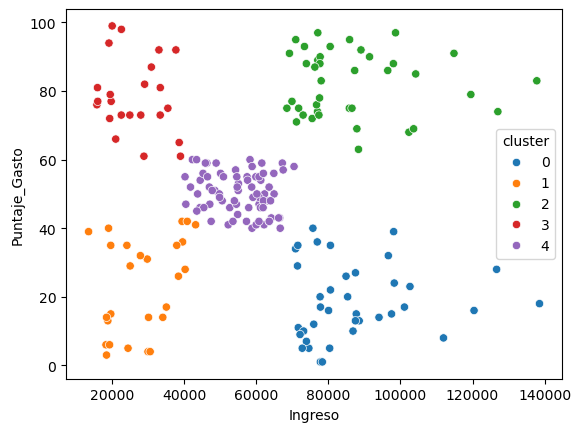

In [57]:
sns.scatterplot(x='Ingreso', y='Puntaje_Gasto', hue='cluster', data=df, palette='tab10')

De los clusters armados por el algoritmo jerarquico aglomerado, podemos sacar las siguientes conclusiones acerca de los clusters y sobre qué grupos centrar una estrategia de marketing:abs

**Sobre los clusters**

- En el análisis general de los datos, puntualmente en el gráfico de correlación, una de las conclusiones fue que la relación entre el ingreso y el puntaje de gasto mostraba un patrón para ciertos grupos de puntos. Justamente, este mismo patrón observado y descrito, fue el que el algoritmo agrupó como clusters.
- Se puede observar que los clusters agruparon muy bien los datos según qué tanto ingreso y puntaje de gasto tienen
- El cluster con mayor cantidad de clientes es el Cluster 4 con 74 mientras que el menor es el cluster 3 con 23 clientes.


**Sobre la estrategia de marketing**

- De acuerdo a los clusters armados yo centraría mi estrategía en aquellos grupos de mayor ingreso y mayos puntaje de gasto, una priorización de clusters en este sentido sería:
    1. Cluster 2
    2. Cluster 4
    3. Cluster 3
    4. Cluster 0
    5. Cluster 1
- Si tuveria que elegir dos grupos puntuales sobre los que centrar mi estrategía, eligiría los Clusters 2 y 4, ya que son los que garantizan mejor relación ingreso / puntaje de gasto
- El cluster 4 desde mi punto de vista es más atractivo para la estrategía que el cluster 3, aunque este último tenga mejor puntaje de gasto, ya que la media de ingresos del cluster 4 dobla la media de ingresos del cluster 3 y la diferencia en puntaje de gasto es de apenas 18 puntos entre ambos. Lo que me garantiza que aunque los del cluster 4 tengan una menor frecuencia de gasto en la tienda, debido a sus ingresos, 

### 4. DBSCAN

Implemente DBSCAN, al igual que el punto anterior sólo dos variables: su ingreso y el puntaje de gastos. Al implementar  justifique su elección de `min_samples` y `eps`. ¿Cuántos grupos o clusters encuentra? ¿Cuáles son su características? ¿Cambiaría su estrategia de marketing respecto al punto anterior? Justifique su respuesta.

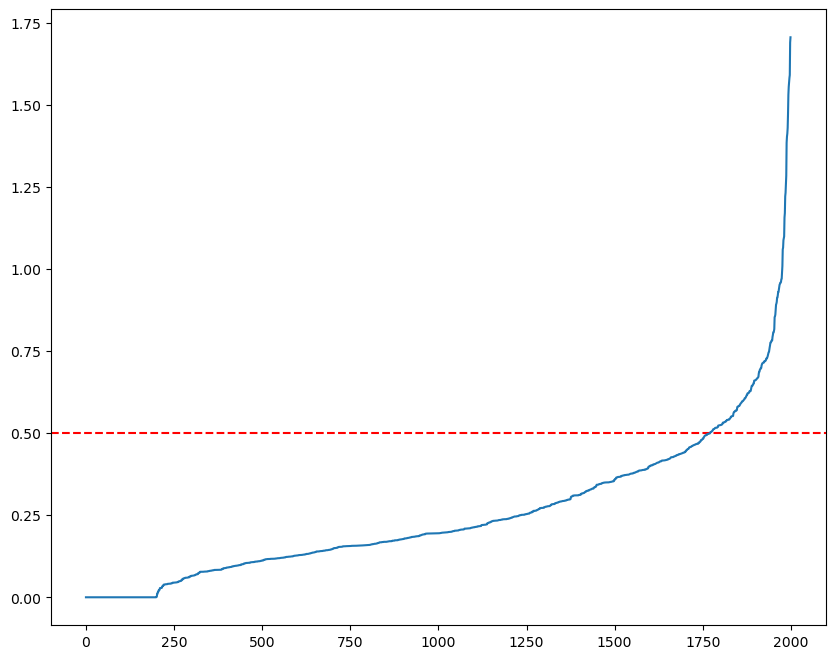

In [61]:
neigh = NearestNeighbors(n_neighbors = 10)
nbrs = neigh.fit(X_scaled)
distancias, indices = nbrs.kneighbors(X_scaled)
distancias = np.sort(distancias.flatten())
fig=plt.figure(figsize=(10,8), dpi= 100, facecolor='w', edgecolor='k')
plt.axhline(y = 0.5, color = 'r', linestyle = '--')
plt.plot(distancias)

In [63]:
i = np.arange(len(distancias))
knee = KneeLocator(i, distancias, S=1, curve='convex', direction='increasing', interp_method='polynomial')

print(distancias[knee.knee])

0.4934968313866966


In [65]:
eps_value = distancias[knee.knee]

# Rango de min_samples a probar
min_samples_range = range(2, 21)

best_score = -1
best_min_samples = None

for m in min_samples_range:
    db = DBSCAN(eps=eps_value, min_samples=m).fit(X_scaled)
    labels = db.labels_
    
    # Evitar casos con 1 solo cluster o solo ruido
    if len(set(labels)) > 1 and len(set(labels)) != 1 + (1 if -1 in labels else 0):
        score = silhouette_score(X_scaled, labels)
        if score > best_score:
            best_score = score
            best_min_samples = m

print("Mejor min_samples:", best_min_samples)
print("Mejor silhouette_score:", best_score)

Mejor min_samples: 12
Mejor silhouette_score: 0.3532308926982962


In [67]:
dbscan = DBSCAN(eps=eps_value, min_samples=best_min_samples)
labels = dbscan.fit_predict(X_scaled)

# Agregar los clusters al DataFrame original
df['cluster_dbscan'] = labels

# Ver cuántos clusters se formaron (excluyendo ruido = -1)
num_clusters = len(set(labels)) - (1 if -1 in labels else 0)
print(f"Número de clusters encontrados: {num_clusters}")
print(df['cluster_dbscan'].value_counts())

Número de clusters encontrados: 4
 0    95
-1    40
 2    30
 3    23
 1    12
Name: cluster_dbscan, dtype: int64


<Axes: xlabel='Ingreso', ylabel='Puntaje_Gasto'>

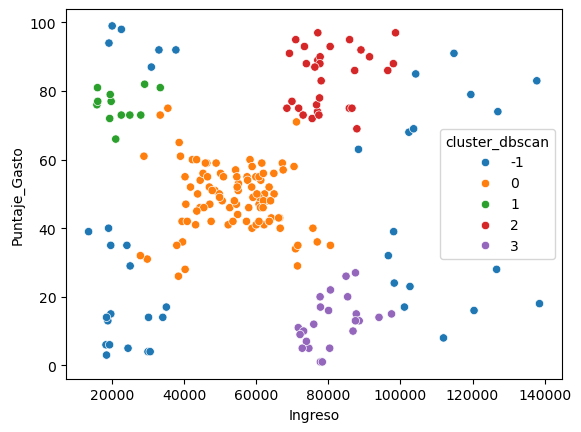

In [69]:
sns.scatterplot(x='Ingreso', y='Puntaje_Gasto', hue='cluster_dbscan', data=df, palette='tab10')

**Grupos de clusters encontrados con DBSCAN: 4**

**Caracteristicas de los clusters encontrados y selección de esp y min_samples**

Se corre el modelo DBSCAN, en el cual se trabajan con valores min_samples y eps determinados de la siguiente manera:

- Para el cálculo del eps, se utiliza el método del gráfico de distancias k-ésimas, el cual nos arroja que el valor óptimo de eps es **0.4934968313866966**
- Para el cálculo del min_samples, se utilizó una estimación de parámetros tomando como base el eps calculado anteriormente e iterando diferentes valores de min_samples y tomando como métrica de desempeño el *silhouette_score*. A partir de estas iteraciones se llega a la conclusión que el mejor valor para min_samples es 12.
- Una vez calculados los parámetros para eps y min_samples se construye el modelo obteniendo como resultado que el número de clusters encontrados es 4 y dejando 40 clientes con clasificación -1. Es decir, el modelo los consideró como ruido o outliers.

**Definición de estrategía según los nuevos resultados**



Esta definición de clusters cambia comparado con los clusters anteriormente calculados, que no dejaron ningún punto como ruido. Con base en esto, yo no cambiaría mi estrategía de marketing y me quedaría con los clusters hallados con el método anterior. Esto lo haría basado en que visualmente, los datos suelen tener una forma más convexa para lo cual el modelo de clustering jerarquico suele tener un mejor desempeño y agrupar los datos. 

Finalmente, esto también se sustenta en que el modelo DBSCAN dejó el 20% de los datos como ruido despreciando el comportamiento de estos clientes que a nivel de estrategía de marketing, y entendiendo que se trabajó con una muestra pequeña, aportan gran valor al análisis.

### 5. Incorporando más dimensiones

Hasta este momento hemos utilizado solo dos variables para nuestro análisis, sin embargo, la base cuenta con otras variables más: género y edad. Usando las categorías de edad creadas anteriormente incorpore género y grupo etario a su análisis. Genere los grupos utilizando DBSCAN y la distancia de Gower, justificando su elección de `min_samples` y `eps`   ¿Incorporar estas variables, ayuda a la focalización de la estrategia de marketing?

In [73]:
df_sub = df[["Ingreso", "Puntaje_Gasto", "Genero", "grupo_etario"]]

In [75]:
df_sub

,Ingreso,Puntaje_Gasto,Genero,grupo_etario
0,98115.05,39,Mujer,35-44
1,35458.14,75,Mujer,18-24
2,59872.08,55,Mujer,65+
3,48508.93,51,Hombre,55-64
4,44431.11,54,Mujer,25-34
...,...,...,...,...
195,19322.17,72,Mujer,25-34
196,43486.37,45,Mujer,45-54
197,24086.95,35,Hombre,35-44
198,38599.28,65,Mujer,18-24


In [77]:
df_gower = df_sub.copy()

for col in df_gower.select_dtypes(include=["category"]).columns:
    df_gower[col] = df_gower[col].astype(str)

gower_dist = gower.gower_matrix(df_gower)

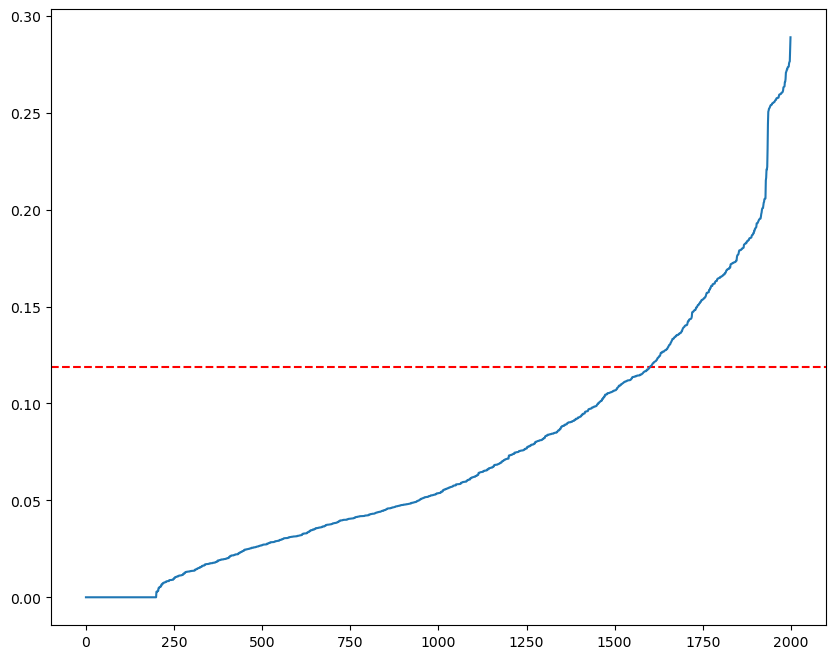

In [79]:
neigh = NearestNeighbors(n_neighbors = 10, metric="precomputed")
nbrs = neigh.fit(gower_dist)
distancias, indices = nbrs.kneighbors(gower_dist)
distancias = np.sort(distancias.flatten())
fig=plt.figure(figsize=(10,8), dpi= 100, facecolor='w', edgecolor='k')
plt.axhline(y = 0.119, color = 'r', linestyle = '--')
plt.plot(distancias)

In [81]:
i = np.arange(len(distancias))
knee = KneeLocator(i, distancias, S=1, curve='convex', direction='increasing', interp_method='polynomial')

print(distancias[knee.knee])

0.11933366


In [83]:
eps_value = distancias[knee.knee]

# Rango de min_samples a probar
min_samples_range = range(2, 21)

best_score = -1
best_min_samples = None

for m in min_samples_range:
    db = DBSCAN(eps=eps_value, min_samples=m).fit(gower_dist)
    labels = db.labels_
    
    # Evitar casos con 1 solo cluster o solo ruido
    if len(set(labels)) > 1 and len(set(labels)) != 1 + (1 if -1 in labels else 0):
        score = silhouette_score(gower_dist, labels)
        if score > best_score:
            best_score = score
            best_min_samples = m

print("Mejor min_samples:", best_min_samples)
print("Mejor silhouette_score:", best_score)

Mejor min_samples: 3
Mejor silhouette_score: -0.15570544


In [85]:
dbscan = DBSCAN(eps=eps_value, min_samples=best_min_samples, metric="precomputed")
labels = dbscan.fit_predict(gower_dist)

df['cluster_dbscan_v2'] = labels

num_clusters = len(set(labels)) - (1 if -1 in labels else 0)
print(f"Número de clusters encontrados: {num_clusters}")
print(df['cluster_dbscan_v2'].value_counts())

Número de clusters encontrados: 14
 4     32
 12    25
 0     22
 1     18
 5     18
 8     18
 6     16
 11    14
 7      8
 13     6
 2      5
 9      5
-1      5
 3      4
 10     4
Name: cluster_dbscan_v2, dtype: int64


<Axes: xlabel='Ingreso', ylabel='Puntaje_Gasto'>

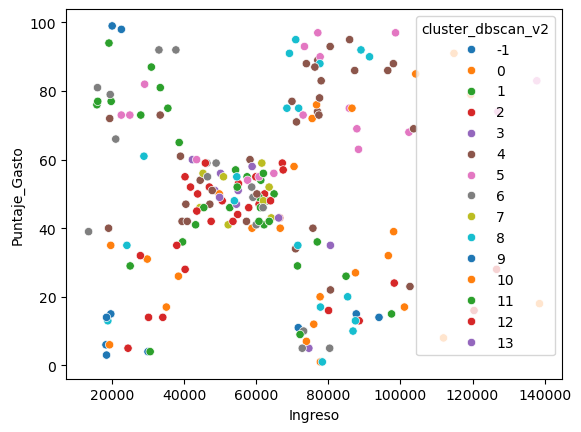

In [87]:
sns.scatterplot(x='Ingreso', y='Puntaje_Gasto', hue='cluster_dbscan_v2', data=df, palette='tab10')

**Procedimiento**

En términos generales el procedimiento utilizado para abordar el punto es el siguiente:

1. Generar una matriz con las nuevas variables. Se utiliza matriz de gower para poder incorporar variables categoricas
2. Escalar o estandarizar la matriz
3. calcular por gráfico de distancias k-ésimas el mejor eps
4. calcular el mejor min_samples
5. construir el modelo DBSCAN

**Seleccion de min_samples y eps**

- Para el cálculo del eps, se utiliza el método del gráfico de distancias k-ésimas, el cual nos arroja que el valor óptimo de eps es **0.11933366**
- Para el cálculo del min_samples, se utilizó una estimación de parámetros tomando como base el eps calculado anteriormente e iterando diferentes valores de min_samples y tomando como métrica de desempeño el *silhouette_score*. A partir de estas iteraciones se llega a la conclusión que el mejor valor para min_samples es 3.

**Focalización estrategia de marketing**

El modelo DBSCAN con las nuevas variables incorporadas, ahora nos dá un número mayor de clusters y vemos que son más focalizados. Sin duda alguna la incorporación de las nuevas variables nos permite llegar con una estrategía de marketing más esfecífica a los clientes. No solamente en función de su comportamiento de puntaje de gasto e ingresos, sino ahora también teniendo un conocimiento mayor del cliente entendiento su género y rango etnario. Esto ayuda a entender mejor el cliente y poderle ofrecer una estrategía de marketing más específica y efectiva a sus necesidades